# Runoff Forecasting

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin

**Course:** Artificial Intelligence, Appalachian State University

**Repository:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

NOAA's National Water Model (NWM) issues hourly short-range streamflow forecasts at lead times 1–18 h across the continental US. Those forecasts contain systematic, lead-dependent errors. Following Han & Morrison (2022), we treat error correction as a sequence-prediction problem: at each issue time we predict the residual `error = USGS_obs − NWM_forecast` for the next 18 hours, then reconstruct the corrected forecast as `NWM + predicted_error`. Three recurrent models (GRU, simple LSTM, stacked LSTM) are trained per station, evaluated against the raw NWM and a persistence baseline, and reported with the standard hydrologic metric panel: CC, NSE, PBIAS, RMSE.

The two stations behave very differently — one has a well-calibrated NWM and the post-processor halves test RMSE; the other is heavily regulated, NWM cannot represent the dam/diversion structure, and the corrector can only remove the mean bias. This contrast is the report's headline finding.

## Setup

In [1]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd RunoffForecastingProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2243, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 2243 (delta 97), reused 5 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2243/2243), 70.38 MiB | 14.24 MiB/s, done.
Resolving deltas: 100% (1756/1756), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/RunoffForecastingProject
 data
'Improved runoff forecasting performance through error predictions using a deep-learning approach.pdf'
 README.md
 RunoffForcastingProject.pdf
 RunoffForecasting.ipynb


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import json

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Reconnaissance

Before building the loader, we inspect one USGS observation file and one monthly
NWM forecast file from each station folder to confirm the raw schema and time layout.

This check is used to verify:
- forecast layout (long vs. wide)
- column names and dtypes
- datetime fields and time coverage
- sampling cadence
- rough streamflow magnitude and likely units

This section is exploratory only; final cleaning, alignment, and unit handling are done in the loader section.

In [3]:
DATA_ROOT = Path("data")

# folder names are NWM reach IDs (NHDPlus COMIDs); paired USGS gauges:
stations = {
    "20380357": "09520500",
    "21609641": "11266500",
}

for nwm_id, usgs_id in stations.items():
    folder = DATA_ROOT / nwm_id
    print("\n" + "=" * 72)
    print(f"{folder}   (paired USGS gauge: {usgs_id})")
    print("=" * 72)

    csvs = sorted(folder.glob("*.csv"))
    usgs_file = next(f for f in csvs if "Strt" in f.name and "EndAt" in f.name)
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]

    print(f"USGS file: {usgs_file.name}")
    print(f"NWM files: {len(nwm_files)}  (first: {nwm_files[0].name}, last: {nwm_files[-1].name})")

    print(f"\n--- USGS {usgs_id} ---")
    usgs_df = pd.read_csv(usgs_file)
    usgs_df.info()
    print(usgs_df.head(3))
    print("...")
    print(usgs_df.tail(3))

    print(f"\n--- NWM forecast (sample: {nwm_files[0].name}) ---")
    nwm_df = pd.read_csv(nwm_files[0])
    print(f"shape: {nwm_df.shape}  ->  {'LONG' if nwm_df.shape[1] <= 5 else 'WIDE'} format")
    print(nwm_df.head(3))

    # parse datetime columns to confirm coverage
    for col in [c for c in nwm_df.columns if "time" in c.lower()]:
        fmt = "%Y-%m-%d_%H:%M:%S" if "model_" in col else None
        t = pd.to_datetime(nwm_df[col], format=fmt, utc=True)
        print(f"  {col}: {t.min()} -> {t.max()}  ({t.nunique()} unique)")

    # quick unit check
    q_max = nwm_df["streamflow_value"].max()
    print(f"  streamflow_value max = {q_max:.2f}  ->  likely {'cfs' if q_max > 1000 else 'cms'}")


data/20380357   (paired USGS gauge: 09520500)
USGS file: 09520500_Strt_2021-04-20_EndAt_2023-04-21.csv
NWM files: 25  (first: streamflow_20380357_202104.csv, last: streamflow_20380357_202304.csv)

--- USGS 09520500 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70089 entries, 0 to 70088
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DateTime       70089 non-null  object 
 1   USGSFlowValue  70089 non-null  float64
 2   USGS_GageID    70089 non-null  object 
dtypes: float64(1), object(2)
memory usage: 1.6+ MB
                    DateTime  USGSFlowValue USGS_GageID
0  2021-04-20 07:00:00+00:00           0.18           A
1  2021-04-20 07:15:00+00:00           0.18           A
2  2021-04-20 07:30:00+00:00           0.19           A
...
                        DateTime  USGSFlowValue USGS_GageID
70086  2023-04-22 06:15:00+00:00           0.15           A
70087  2023-04-22 06:30:00+00:00           0.15     

## Data Preparation

This section converts the raw NWM forecast files and USGS observations into a
single tidy hourly table for each station. The main steps are:
- parse NWM issue times and valid times, drop duplicate (init_time, lead_h) rows and duplicate USGS timestamps
- resample USGS observations from 15-minute to hourly cadence
- align NWM forecasts with USGS observations on `valid_time`
- compute forecast residuals as `error = usgs_q - nwm_q`

The resulting tidy tables are saved for downstream splitting, windowing, model
training, and evaluation.

In [4]:
NWM_DT_FMT = "%Y-%m-%d_%H:%M:%S"  # underscore separator; explicit format avoids the slow dateutil fallback

def load_usgs_hourly(usgs_file):
    df = pd.read_csv(usgs_file)
    df["DateTime"] = pd.to_datetime(df["DateTime"], utc=True)
    s = df.set_index("DateTime")["USGSFlowValue"].sort_index()
    n_dup = int(s.index.duplicated().sum())
    s = s[~s.index.duplicated(keep="first")]
    return s.asfreq("h").rename("usgs_q"), n_dup

def load_nwm_station(folder):
    parts = []
    for f in sorted(folder.glob("streamflow_*.csv")):
        df = pd.read_csv(f)
        df["init_time"]  = pd.to_datetime(df["model_initialization_time"], format=NWM_DT_FMT, utc=True)
        df["valid_time"] = pd.to_datetime(df["model_output_valid_time"],   format=NWM_DT_FMT, utc=True)
        df["lead_h"] = ((df["valid_time"] - df["init_time"]).dt.total_seconds() // 3600).astype(int)
        df = df.rename(columns={"streamflow_value": "nwm_q"})
        parts.append(df[["init_time", "valid_time", "lead_h", "nwm_q"]])
    nwm = pd.concat(parts, ignore_index=True)
    n_dup = int(nwm.duplicated(["init_time", "lead_h"]).sum())
    nwm = (nwm.drop_duplicates(["init_time", "lead_h"])
              .sort_values(["init_time", "lead_h"])
              .reset_index(drop=True))
    return nwm, n_dup

for nwm_id, usgs_id in stations.items():
    folder = DATA_ROOT / nwm_id
    csvs = sorted(folder.glob("*.csv"))
    nwm_files = [f for f in csvs if f.name.startswith("streamflow_")]
    usgs_file = [f for f in csvs if f not in nwm_files][0]

    usgs, n_usgs_dup = load_usgs_hourly(usgs_file)
    nwm, n_nwm_dup = load_nwm_station(folder)

    df = nwm.merge(usgs, left_on="valid_time", right_index=True, how="left")
    df["error"] = df["usgs_q"] - df["nwm_q"]
    df = df[["valid_time", "init_time", "lead_h", "nwm_q", "usgs_q", "error"]]

    out = folder / f"tidy_{nwm_id}.parquet"
    df.to_parquet(out)

    print(f"\n=== Station {nwm_id} (USGS {usgs_id}) ===")
    print(f"NWM duplicates dropped (init_time, lead_h):  {n_nwm_dup:,}")
    print(f"USGS duplicate timestamps dropped:           {n_usgs_dup:,}")
    print(f"rows: {len(df):,}   inits: {df['init_time'].nunique():,}   leads: {df['lead_h'].min()}..{df['lead_h'].max()}")
    print(f"valid_time: {df['valid_time'].min()} -> {df['valid_time'].max()}")
    print(f"missing usgs_q: {df['usgs_q'].isna().sum():,} ({df['usgs_q'].isna().mean():.1%})")

    lead1 = df[df["lead_h"] == 1].dropna()
    print(f"lead_h=1 (n={len(lead1):,}): nwm med={lead1['nwm_q'].median():.3f}  usgs med={lead1['usgs_q'].median():.3f}  error mean={lead1['error'].mean():+.3f}")
    print(f"wrote: {out}")


=== Station 20380357 (USGS 09520500) ===
NWM duplicates dropped (init_time, lead_h):  10,371
USGS duplicate timestamps dropped:           0
rows: 315,789   inits: 17,544   leads: 1..18
valid_time: 2021-04-21 01:00:00+00:00 -> 2023-04-22 17:00:00+00:00
missing usgs_q: 1,164 (0.4%)
lead_h=1 (n=17,483): nwm med=3.930  usgs med=0.240  error mean=-4.840
wrote: data/20380357/tidy_20380357.parquet

=== Station 21609641 (USGS 11266500) ===
NWM duplicates dropped (init_time, lead_h):  10,371
USGS duplicate timestamps dropped:           0
rows: 315,789   inits: 17,544   leads: 1..18
valid_time: 2021-04-21 01:00:00+00:00 -> 2023-04-22 17:00:00+00:00
missing usgs_q: 18,372 (5.8%)
lead_h=1 (n=16,527): nwm med=6.300  usgs med=7.080  error mean=+0.282
wrote: data/21609641/tidy_21609641.parquet


## Descriptive Statistics

Before visualizing, we tabulate per-station summary statistics for the lead-1
hourly series. The goal is to make the basin contrast (small headwater vs.
larger river) explicit in numbers, not only in the EDA plots that follow:

- standard descriptive table (`.describe()`) on each feature
- monthly hour-count pivot to confirm coverage matches the project window
- flow quantiles for `nwm_q` and `usgs_q` so the downstream split's tail
  behavior at flood peaks is documented

In [5]:
def load_tidy(station_id):
    df = pd.read_parquet(DATA_ROOT / station_id / f"tidy_{station_id}.parquet")
    df = df[df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[["nwm_q", "usgs_q", "error"]]

for sid in stations:
    df = load_tidy(sid)
    print(f"\n{'='*70}\nstation {sid} — lead-1 hourly series ({len(df):,} hours)\n{'='*70}")

    print("\nFeature summary (cms for nwm_q / usgs_q / error):")
    print(df[["nwm_q", "usgs_q", "error"]].describe().round(3).to_string())

    monthly = df.assign(month=df.index.to_period("M")).groupby("month").size().rename("n_hours")
    print(f"\nMonthly hour count — first 6 / last 6 of {len(monthly)} months:")
    print(monthly.head(6).to_string())
    print("  ...")
    print(monthly.tail(6).to_string())

    qtbl = df[["nwm_q", "usgs_q"]].quantile([0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(3)
    qtbl.index.name = "quantile"
    print(f"\nFlow quantiles (cms):")
    print(qtbl.to_string())


station 20380357 — lead-1 hourly series (17,544 hours)

Feature summary (cms for nwm_q / usgs_q / error):
           nwm_q     usgs_q      error
count  17544.000  17483.000  17483.000
mean       5.680      0.253     -4.840
std       13.043      0.142      6.293
min        0.300      0.050   -207.410
25%        2.300      0.180     -5.600
50%        3.930      0.240     -3.700
75%        5.830      0.310     -2.050
max      299.390      4.080      0.180

Monthly hour count — first 6 / last 6 of 25 months:
month
2021-04    239
2021-05    744
2021-06    720
2021-07    744
2021-08    744
2021-09    720
Freq: M
  ...
month
2022-11    720
2022-12    744
2023-01    744
2023-02    672
2023-03    744
2023-04    505
Freq: M

Flow quantiles (cms):
           nwm_q  usgs_q
quantile                
0.05       0.770   0.100
0.25       2.300   0.180
0.50       3.930   0.240
0.75       5.830   0.310
0.95      12.840   0.430
0.99      35.041   0.582

station 21609641 — lead-1 hourly series (17,544 hou

/tmp/ipykernel_575/2961736622.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.assign(month=df.index.to_period("M")).groupby("month").size().rename("n_hours")
/tmp/ipykernel_575/2961736622.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.assign(month=df.index.to_period("M")).groupby("month").size().rename("n_hours")


## Exploratory Data Analysis

This section visualizes the hourly lead-1 series for each station after alignment.
The goals are to:
- compare raw NWM forecasts against USGS observations
- inspect the residual series `error = usgs_q - nwm_q`
- summarize missing observations before imputation
- examine residual autocorrelation to assess whether a short input window such as `L = 6` is reasonable

Train, validation, and test periods are shaded to make the chronological split visible.

Missing-data summary (raw, before forward-fill):
  20380357: 61 / 17,544 hours missing USGS (0.3%)
  21609641: 1,017 / 17,544 hours missing USGS (5.8%)


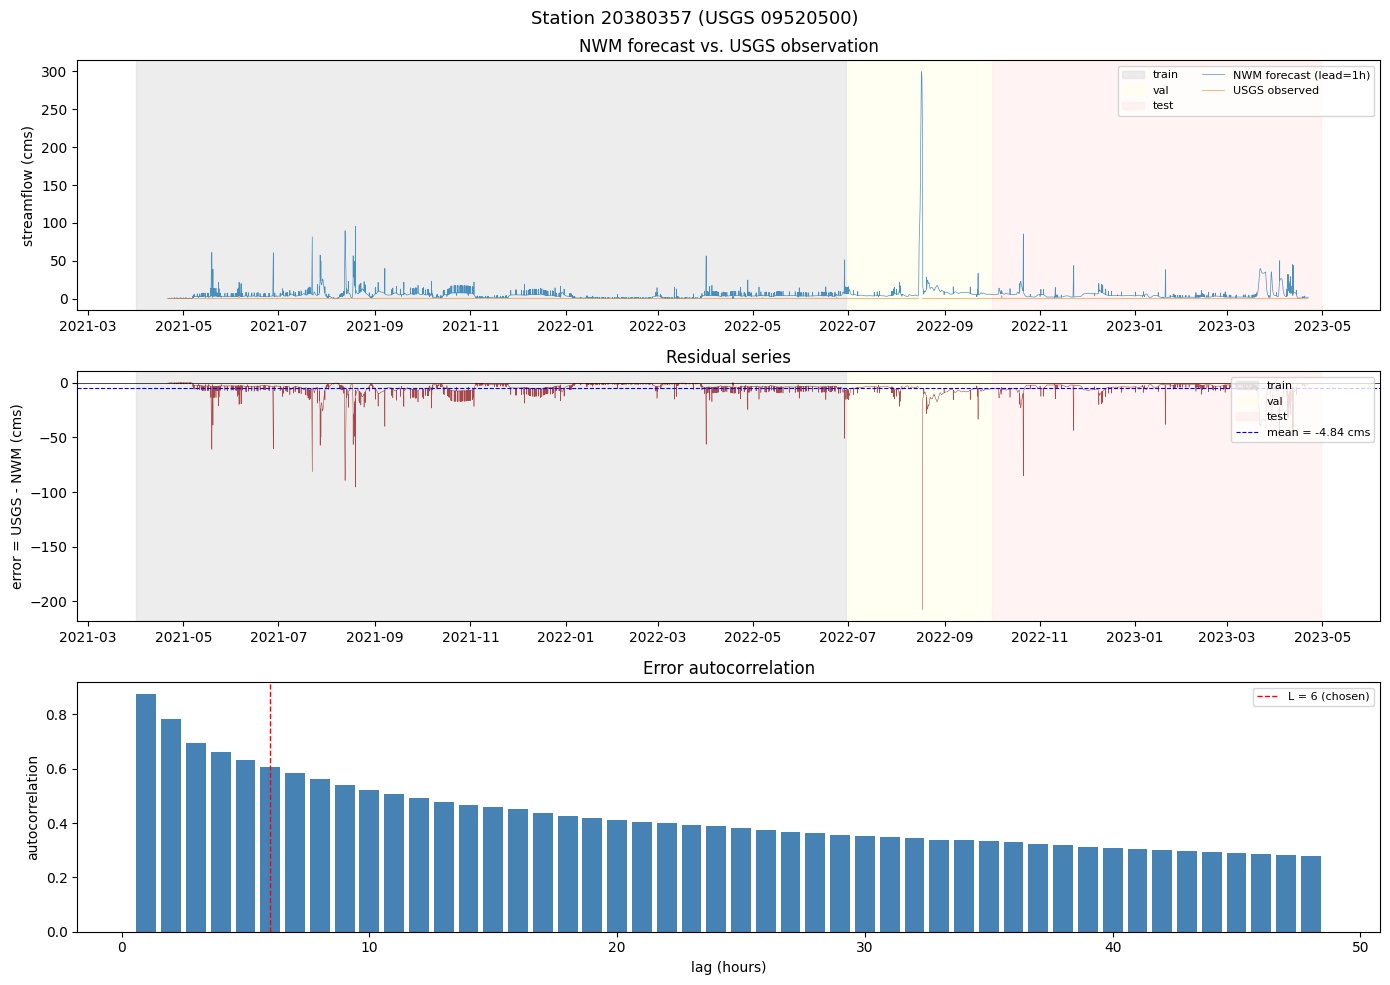

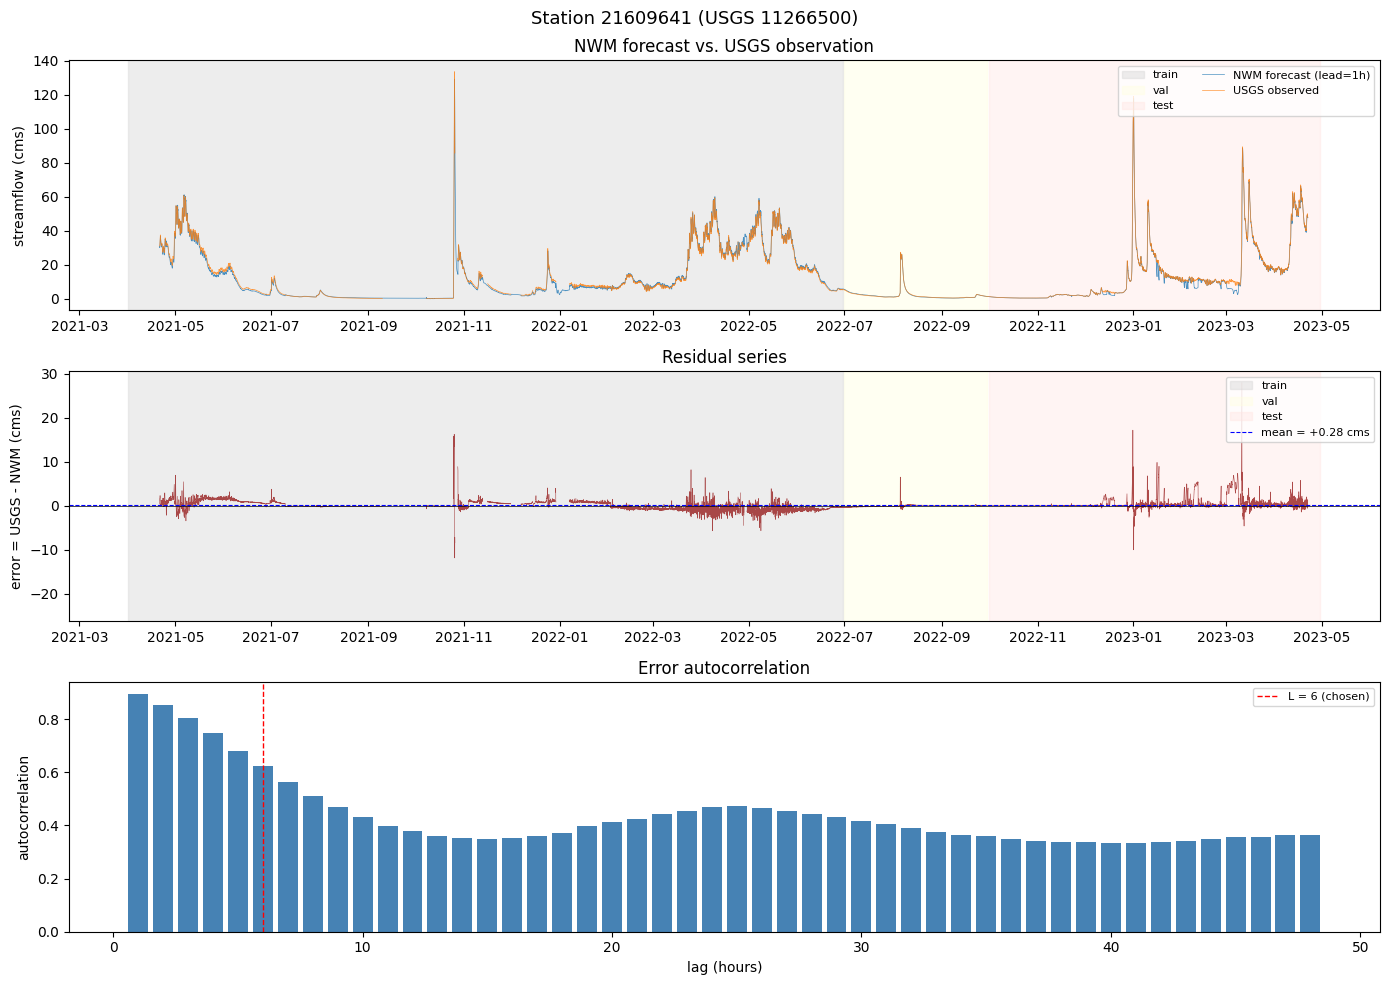

In [6]:
SPLITS = [
    ("2021-04", "2022-06", "lightgray",   "train"),
    ("2022-07", "2022-09", "lightyellow", "val"),
    ("2022-10", "2023-04", "mistyrose",   "test"),
]

def shade_splits(ax):
    for start, end, color, label in SPLITS:
        ax.axvspan(pd.Timestamp(start, tz="UTC"),
                   pd.Timestamp(end,   tz="UTC") + pd.offsets.MonthEnd(0),
                   alpha=0.4, color=color, label=label)

def plot_station(df, station_id, usgs_id):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f"Station {station_id} (USGS {usgs_id})", fontsize=13)

    ax = axes[0]
    shade_splits(ax)
    ax.plot(df.index, df["nwm_q"],  lw=0.5, alpha=0.8, label="NWM forecast (lead=1h)")
    ax.plot(df.index, df["usgs_q"], lw=0.5, alpha=0.8, label="USGS observed")
    ax.set_ylabel("streamflow (cms)")
    ax.set_title("NWM forecast vs. USGS observation")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax = axes[1]
    shade_splits(ax)
    ax.plot(df.index, df["error"], lw=0.4, color="darkred", alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(df["error"].mean(), color="blue", lw=0.8, ls="--",
               label=f"mean = {df['error'].mean():+.2f} cms")
    ax.set_ylabel("error = USGS - NWM (cms)")
    ax.set_title("Residual series")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    ax = axes[2]
    err = df["error"].dropna().values
    err = err - err.mean()
    var = (err ** 2).mean()
    lags = np.arange(1, 49)
    acf = np.array([(err[:-k] * err[k:]).mean() / var for k in lags])
    ax.bar(lags, acf, width=0.8, color="steelblue")
    ax.axhline(0, color="black", lw=0.5)
    ax.axvline(6, color="red", lw=1, ls="--", label="L = 6 (chosen)")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("autocorrelation")
    ax.set_title("Error autocorrelation")
    ax.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

print("Missing-data summary (raw, before forward-fill):")
for sid in stations:
    df = load_tidy(sid)
    n, n_missing = len(df), df["usgs_q"].isna().sum()
    print(f"  {sid}: {n_missing:,} / {n:,} hours missing USGS ({n_missing/n:.1%})")

for sid, usgs_id in stations.items():
    plot_station(load_tidy(sid), sid, usgs_id)

## Outlier Analysis

The residual series shown above contains visible flood-peak excursions. We
quantify these formally on the **training period only** so the diagnostic is
leakage-free, using two standard methods:

- **Tukey IQR fence** (Q1 − 1.5·IQR, Q3 + 1.5·IQR) — non-parametric, robust
  to skew
- **|z| > 3** — parametric reference for comparison

Treatment policy: outliers are **retained, not removed**. They correspond to
flood-peak events, which are the operationally important regime for runoff
forecasting — discarding them would defeat the purpose of the post-processor.
The training loss is **Huber** (cell 17), which down-weights large residuals
without dropping them, making the model robust to flood-peak influence
without losing signal at the tails.

In [7]:
TRAIN_END = "2022-06"

print("Outlier analysis on training-set residuals (lead_h=1):\n")
print(f"  {'station':<12}  {'n':>8}  {'min':>8}  {'max':>8}  {'IQR fence':>20}  {'n_iqr':>7}  {'%_iqr':>6}  {'n_z3':>7}  {'%_z3':>6}")
for sid in stations:
    df = load_tidy(sid).loc[:TRAIN_END]
    err = df["error"].dropna().values

    q1, q3 = np.percentile(err, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = int(((err < lo) | (err > hi)).sum())

    z = (err - err.mean()) / err.std()
    n_z3 = int((np.abs(z) > 3).sum())

    print(f"  {sid:<12}  {len(err):>8,}  {err.min():>8.2f}  {err.max():>8.2f}  "
          f"[{lo:>7.2f},{hi:>7.2f}]  {n_iqr:>7,}  {100*n_iqr/len(err):>5.1f}%  "
          f"{n_z3:>7,}  {100*n_z3/len(err):>5.1f}%")

Outlier analysis on training-set residuals (lead_h=1):

  station              n       min       max             IQR fence    n_iqr   %_iqr     n_z3    %_z3
  20380357        10,463    -95.45      0.18  [ -10.14,   3.78]      418    4.0%      146    1.4%
  21609641         9,446    -23.57     16.30  [  -2.43,   2.77]      265    2.8%      120    1.3%


## Chronological Train/Validation/Test Split

To prevent temporal leakage, each station’s tidy hourly table is split
chronologically using `valid_time` as the index.

Following the project specification:
- training and validation use April 2021 through September 2022
- testing uses October 2022 through April 2023

The validation set is taken from the most recent portion of the pre-test period,
which follows the common time-series convention of validating on the latest
available training-era data.

In [8]:
TRAIN_RANGE = ("2021-04", "2022-06")
VALID_RANGE = ("2022-07", "2022-09")
TEST_RANGE  = ("2022-10", "2023-04")

def split_station(sid):
    df = pd.read_parquet(DATA_ROOT / sid / f"tidy_{sid}.parquet")
    df = df.set_index("valid_time").sort_index()
    return (df.loc[TRAIN_RANGE[0]:TRAIN_RANGE[1]],
            df.loc[VALID_RANGE[0]:VALID_RANGE[1]],
            df.loc[TEST_RANGE[0]:TEST_RANGE[1]])

def report(name, df):
    n_days = df.index.normalize().nunique()
    print(f"  {name:6s}: {len(df):>7,} rows | {df.index.min()} -> {df.index.max()} | {n_days} unique days")

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
    train, valid, test = split_station(sid)
    for name, part in [("train", train), ("valid", valid), ("test", test)]:
        report(name, part)
        part.reset_index().to_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
    print(f"  wrote: train_/valid_/test_{sid}.parquet")


station 20380357
  train : 188,181 rows | 2021-04-21 01:00:00+00:00 -> 2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00 -> 2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00 -> 2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_20380357.parquet

station 21609641
  train : 188,181 rows | 2021-04-21 01:00:00+00:00 -> 2022-06-30 23:00:00+00:00 | 436 unique days
  valid :  39,744 rows | 2022-07-01 00:00:00+00:00 -> 2022-09-30 23:00:00+00:00 | 92 unique days
  test  :  87,864 rows | 2022-10-01 00:00:00+00:00 -> 2023-04-22 17:00:00+00:00 | 204 unique days
  wrote: train_/valid_/test_21609641.parquet


## Sequencing Window and Dataset Construction

We construct sliding-window training samples from each split. The input window has length L=6 hours; the target horizon is H=18 hours; lead_h=1 rows are used (one row per valid_time) to give a clean per-hour series.

**Temporal layout (no leakage).** Input features at sample i are observed at times t−5 through t — the recent past, including residuals (`error`), NWM forecasts (`nwm_q`), and USGS observations (`usgs_q`). Targets at sample i are residuals at times t+1 through t+18 — the future. The model never sees future `usgs_q` or future `error`. Operationally this corresponds to: at forecast issue time, post-process using the most recent six hours of gauge observations and NWM forecast values.

**Note on lead-time semantics.** "Lead = h hours" in our results refers to the h-hours-ahead prediction horizon from the input window, *not* the NWM short-range forecast lead-time index. Our setup uses `lead_h=1` rows from the NWM throughout — i.e., for each future hour t+h we use the NWM forecast issued at t+h−1 valid for t+h. Whether to additionally vary the NWM lead-time used as input is identified as future work.

**Normalization.** Features are z-scored using train-set statistics only; targets are kept in raw cms so predictions are directly interpretable as flow corrections.

In [9]:
L = 6
H = 18
BATCH_SIZE = 128

FEATURE_COLS = ["error", "nwm_q", "usgs_q"]
TARGET_COL = "error"

def prepare_features(split_df):
    # collapse to one row per hour at lead_h=1; forward/back-fill USGS gaps
    df = split_df[split_df["lead_h"] == 1].set_index("valid_time").sort_index()
    return df[FEATURE_COLS].ffill().bfill()

def build_seq2seq_targets(series, L, H):
    # row i  ==  series[i+L : i+L+H]
    N = len(series)
    n_windows = N - L - H + 1
    out = np.empty((n_windows, H), dtype=np.float32)
    for h in range(H):
        out[:, h] = series[L + h : N - H + 1 + h]
    return out

datasets = {sid: {} for sid in stations}
norm_stats = {}

for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

    splits = {name: pd.read_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
              for name in ("train", "valid", "test")}
    feats = {name: prepare_features(df) for name, df in splits.items()}

    mean = feats["train"].mean().values
    std = feats["train"].std().replace(0.0, 1.0).values
    norm_stats[sid] = (mean, std)

    for name, df in feats.items():
        x = ((df.values - mean) / std).astype(np.float32)
        # targets stay in raw cms so predictions are directly in physical units
        y_series = df[TARGET_COL].values.astype(np.float32)
        targets = build_seq2seq_targets(y_series, L, H)
        datasets[sid][name] = tf.keras.utils.timeseries_dataset_from_array(
            data=x[:-H],
            targets=targets,
            sequence_length=L,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            seed=42,
        )

    print(f"  L={L}  H={H}  batch={BATCH_SIZE}")
    print(f"  features={FEATURE_COLS}   target={TARGET_COL} (raw cms)")
    print(f"  train norm stats:")
    for col, m, s in zip(FEATURE_COLS, mean, std):
        print(f"    {col:8s}  mean={m:8.3f}   std={s:8.3f}")
    print(f"  dataset shapes:")
    for name, ds in datasets[sid].items():
        x_batch, y_batch = next(iter(ds))
        n_batches = sum(1 for _ in ds)
        print(f"    {name:6s}  batches={n_batches:>4}   x={tuple(x_batch.shape)}   y={tuple(y_batch.shape)}")


station 20380357
  L=6  H=18  batch=128
  features=['error', 'nwm_q', 'usgs_q']   target=error (raw cms)
  train norm stats:
    error     mean=  -4.183   std=   5.547
    nwm_q     mean=   4.452   std=   5.545
    usgs_q    mean=   0.270   std=   0.132
  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)

station 21609641
  L=6  H=18  batch=128
  features=['error', 'nwm_q', 'usgs_q']   target=error (raw cms)
  train norm stats:
    error     mean=   0.212   std=   1.513
    nwm_q     mean=  13.158   std=  14.573
    usgs_q    mean=  13.374   std=  14.441
  dataset shapes:
    train   batches=  82   x=(128, 6, 3)   y=(128, 18)
    valid   batches=  18   x=(128, 6, 3)   y=(128, 18)
    test    batches=  38   x=(128, 6, 3)   y=(128, 18)


## Baselines: Raw NWM and Persistence

Two non-trivial baselines are saved alongside the DL models so the eval cell can compare apples-to-apples:

- **Raw NWM** — the un-corrected NWM forecast, equivalent to `error_pred = 0`. Tells us whether the post-processor improves on the operational NWM forecast at all.
- **Persistence** — forecast at horizon h = the last observed USGS value at issue time, held flat for h ∈ 1..18. This is the textbook hydrologic baseline. A model that beats raw NWM but loses to persistence has only learned that observed values are autocorrelated, not anything specific about NWM bias structure.

In [10]:
for sid in stations:
    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)

    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    usgs_series = test_feats["usgs_q"].values.astype(np.float32)
    n_windows = nwm_grid.shape[0]

    # raw NWM: error_pred = 0 (no post-processing applied)
    raw_nwm_preds = np.zeros((n_windows, H), dtype=np.float32)
    np.save(DATA_ROOT / sid / f"preds_raw_nwm_{sid}.npy", raw_nwm_preds)

    # persistence: forecast t+h = USGS observed at issue time t (held flat over h),
    # implying error_pred[t, h] = usgs_q[t] - nwm_q[t+h].
    last_obs = usgs_series[L - 1 : L - 1 + n_windows]
    persistence_forecast = np.broadcast_to(last_obs[:, None], (n_windows, H))
    persistence_preds = (persistence_forecast - nwm_grid).astype(np.float32)
    np.save(DATA_ROOT / sid / f"preds_persistence_{sid}.npy", persistence_preds)

    print(f"  {sid}: raw_nwm{raw_nwm_preds.shape}  persistence{persistence_preds.shape}")

  20380357: raw_nwm(4850, 18)  persistence(4850, 18)
  21609641: raw_nwm(4850, 18)  persistence(4850, 18)


## GRU, LSTM Simple, and Stacked LSTM

Three recurrent architectures are trained per station, all predicting the 18-hour residual error sequence directly via a Dense head:

- **GRU**: `GRU(32) → Dense(18)` — NB2 model zoo entry 5.
- **LSTM simple**: `LSTM(32) → Dense(18)` — NB2 entry 5 with an LSTM cell in place of the GRU.
- **Stacked LSTM**: `LSTM(32, return_sequences=True) → LSTM(32) → Dense(18)` — NB2 entry 3.

All three architectures use 32 recurrent units, following Han & Morrison's published sensitivity analysis. The architectures are deliberately shallow: with roughly 10,500 training windows, deeper networks tend to overfit.

Training configuration:

- Loss: Huber (robust to flood-peak outliers)
- Optimizer: Adam, learning rate `1e-3`, `clipnorm=1.0` (gradient clipping for RNN training stability)
- Metric: MAE (in raw `cms`, since targets are unnormalized)
- Callbacks: `EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True)` and `ReduceLROnPlateau(factor=0.5, patience=5)`
- `clear_session()` and `set_seed(42)` before each model build, per Géron NB2 convention

For each `(station, model)` pair, the trained model and its test-set predictions are saved alongside the persistence baseline so all forecasts can be compared through a single downstream evaluation pipeline.

In [11]:
EPOCHS = 200
UNITS = 32  # paper's optimum for both architectures

def build_gru(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.GRU(UNITS),
        tf.keras.layers.Dense(H),
    ])

def build_lstm_simple(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.LSTM(UNITS),
        tf.keras.layers.Dense(H),
    ])

def build_lstm_stacked(n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, n_features)),
        tf.keras.layers.LSTM(UNITS, return_sequences=True),
        tf.keras.layers.LSTM(UNITS),
        tf.keras.layers.Dense(H),
    ])

model_builders = {"gru": build_gru, "lstm_simple": build_lstm_simple, "lstm_stacked": build_lstm_stacked}

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs visible: {len(gpus)}")

n_features = len(FEATURE_COLS)
summary = {}

histories = {}
for sid in stations:
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")
    for model_name, build in model_builders.items():
        print(f"\n{'-'*70}\n  {sid}  /  {model_name}\n{'-'*70}")

        model = build(n_features)
        model.compile(
            loss=tf.keras.losses.Huber(),
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
            metrics=["mae"],
        )
        model.summary(line_length=70)

        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5),
        ]

        history = model.fit(
            datasets[sid]["train"],
            validation_data=datasets[sid]["valid"],
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=2,
        )
        histories[(sid, model_name)] = history.history
        with open(DATA_ROOT / sid / f"hist_{model_name}_{sid}.json", "w") as f:
          json.dump(history.history, f)

        _, val_mae = model.evaluate(datasets[sid]["valid"], verbose=0)
        _, test_mae = model.evaluate(datasets[sid]["test"], verbose=0)

        model.save(DATA_ROOT / sid / f"{model_name}_{sid}.keras")
        preds = model.predict(datasets[sid]["test"], verbose=0)
        np.save(DATA_ROOT / sid / f"preds_{model_name}_{sid}.npy", preds)

        summary[(sid, model_name)] = (val_mae, test_mae)
        print(f"  val_mae:  {val_mae:.4f} cms")
        print(f"  test_mae: {test_mae:.4f} cms")

print(f"\n{'='*70}\nfinal MAE summary (cms, lower=better)\n{'='*70}")
print(f"  {'station':<12} {'model':<14} {'val_mae':>10} {'test_mae':>10}")
for (sid, name), (vm, tm) in summary.items():
    print(f"  {sid:<12} {name:<14} {vm:>10.4f} {tm:>10.4f}")

GPUs visible: 1

station 20380357

----------------------------------------------------------------------
  20380357  /  gru
----------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ gru (GRU)                    │ (None, 32)            │       3,552 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 4,146 (16.20 KB)

 Trainable params: 4,146 (16.20 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm (LSTM)                  │ (None, 6, 32)         │       4,608 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ lstm_1 (LSTM)                │ (None, 32)            │       8,320 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 18)            │         594 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 13,522 (52.82 KB)

 Trainable params: 13,522 (52.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
82/82 - 4s - 48ms/step - loss: 0.3564 - mae: 0.6375 - val_loss: 0.0290 - val_mae: 0.1582 - learning_rate: 0.0010
Epoch 2/200
82/82 - 2s - 25ms/step - loss: 0.2449 - mae: 0.4342 - val_loss: 0.0227 - val_mae: 0.1008 - learning_rate: 0.0010
Epoch 3/200
82/82 - 2s - 23ms/step - loss: 0.2294 - mae: 0.4066 - val_loss: 0.0202 - val_mae: 0.0578 - learning_rate: 0.0010
Epoch 4/200
82/82 - 3s - 32ms/step - loss: 0.2200 - mae: 0.3933 - val_loss: 0.0201 - val_mae: 0.0529 - learning_rate: 0.0010
Epoch 5/200
82/82 - 2s - 29ms/step - loss: 0.2137 - mae: 0.3857 - val_loss: 0.0204 - val_mae: 0.0611 - learning_rate: 0.0010
Epoch 6/200
82/82 - 2s - 24ms/step - loss: 0.2095 - mae: 0.3793 - val_loss: 0.0192 - val_mae: 0.0587 - learning_rate: 0.0010
Epoch 7/200
82/82 - 2s - 23ms/step - loss: 0.2064 - mae: 0.3759 - val_loss: 0.0189 - val_mae: 0.0598 - learning_rate: 0.0010
Epoch 8/200
82/82 - 2s - 23ms/step - loss: 0.2018 - mae: 0.3700 - val_loss: 0.0190 - val_mae: 0.0578 - learning_rate: 0.0010


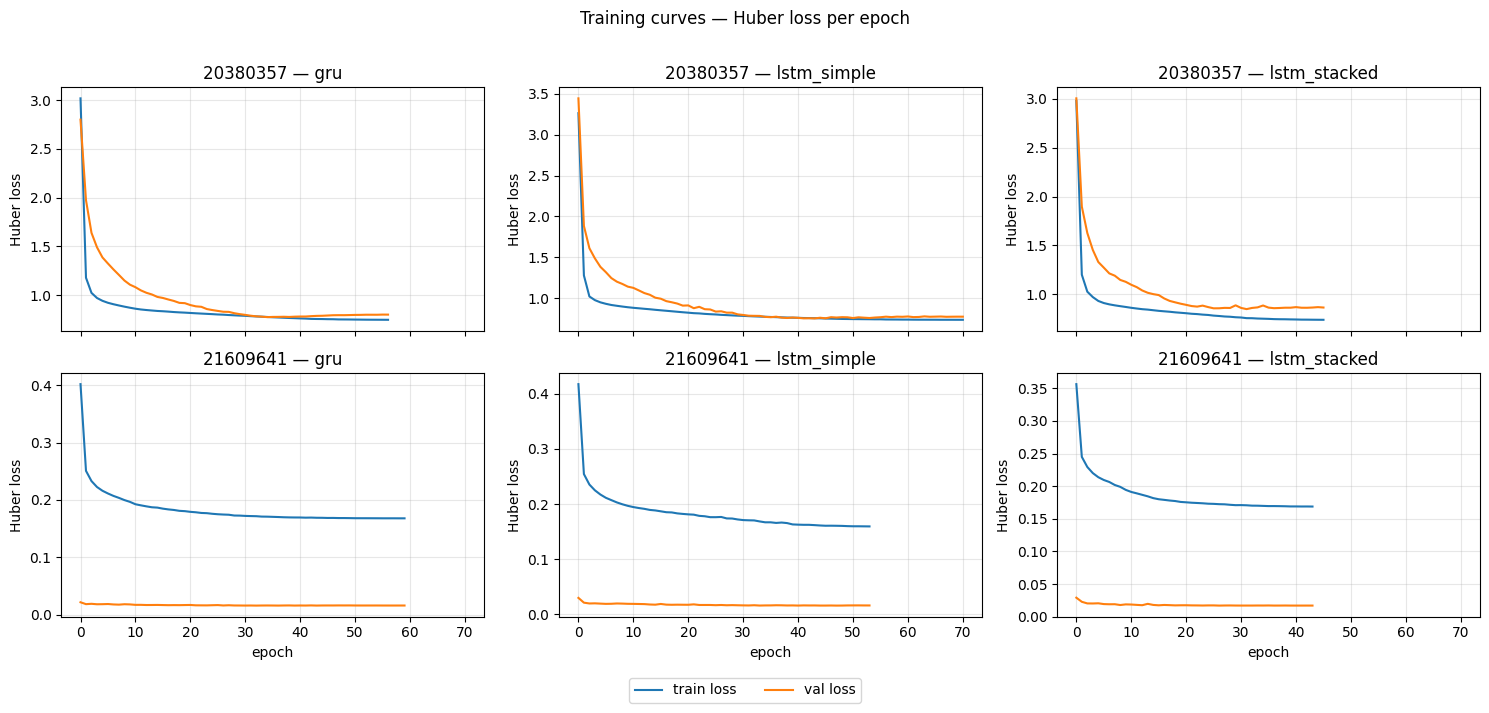

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
fig.suptitle("Training curves — Huber loss per epoch", fontsize=12)
for r, sid in enumerate(stations):
    for c, model_name in enumerate(["gru", "lstm_simple", "lstm_stacked"]):
        h = histories[(sid, model_name)]
        ax = axes[r, c]
        ax.plot(h["loss"], color="C0", label="train loss")
        ax.plot(h["val_loss"], color="C1", label="val loss")
        ax.set_title(f"{sid} — {model_name}")
        ax.set_ylabel("Huber loss")
        ax.grid(alpha=0.3)
        if r == 1:
            ax.set_xlabel("epoch")
fig.legend(["train loss", "val loss"], loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## Hyperparameter Studies

The headline models in cell 17 use Han & Morrison's published values directly:
`units=32`, `lr=1e-3`, `dropout=0`, `L=6`. Whether those values transfer to
our basin is an empirical question. This section runs two sub-studies:

1. **Random search over architectural HPs** — `units`, `lr`, `dropout` —
   on the GRU at station 21609641, our well-calibrated basin. 15-trial
   `keras_tuner.RandomSearch`, validation MAE as objective. The best HP
   set is then retrained at full budget and compared against the paper-
   default GRU from cell 17.

2. **Input sequence length sensitivity** — sweep `L ∈ {6, 12, 18, 24}` on
   the GRU at *both* stations. The ACF plot in cell 9 hinted that station
   21609641 has daily seasonality that L=6 cannot capture, but station
   20380357 has different dynamics; the sweep documents whether the
   gradient direction is consistent across basins.

All other knobs are held at the paper's values during each sub-study.

In [13]:
!pip install -q keras_tuner
import keras_tuner as kt

TUNE_STATION = "21609641"
SEARCH_TRIALS = 15
SEARCH_EPOCHS = 60

def build_gru_hp(hp):
    units   = hp.Choice("units",   [16, 32, 64])
    lr      = hp.Choice("lr",      [3e-4, 1e-3, 3e-3])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2])
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L, len(FEATURE_COLS))),
        tf.keras.layers.GRU(units, dropout=dropout),
        tf.keras.layers.Dense(H),
    ])
    model.compile(
        loss=tf.keras.losses.Huber(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        metrics=["mae"],
    )
    return model

tuner = kt.RandomSearch(
    build_gru_hp,
    objective=kt.Objective("val_mae", direction="min"),
    max_trials=SEARCH_TRIALS,
    seed=42,
    overwrite=True,
    directory="kt",
    project_name=f"gru_{TUNE_STATION}",
)

tuner.search(
    datasets[TUNE_STATION]["train"],
    validation_data=datasets[TUNE_STATION]["valid"],
    epochs=SEARCH_EPOCHS,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=10, restore_best_weights=True)],
    verbose=0,
)

print(f"GRU random search @ station {TUNE_STATION} — top 5 trials by val_mae:")
print(f"  {'units':>6}  {'lr':>8}  {'dropout':>8}  {'val_mae':>10}")
for trial in tuner.oracle.get_best_trials(5):
    h = trial.hyperparameters.values
    print(f"  {h['units']:>6}  {h['lr']:>8.0e}  {h['dropout']:>8.2f}  {trial.score:>10.4f}")

best_hp = tuner.get_best_hyperparameters(1)[0]
print(f"\nBest HPs: units={best_hp['units']}, lr={best_hp['lr']:.0e}, dropout={best_hp['dropout']:.2f}")

# Retrain best at full budget so the comparison is apples-to-apples with cell 20.
print(f"\nRetraining best HPs at full budget (epochs={EPOCHS}, patience=20)...")
tf.keras.backend.clear_session()
tf.random.set_seed(42)
best_model = tuner.hypermodel.build(best_hp)
hist_best = best_model.fit(
    datasets[TUNE_STATION]["train"],
    validation_data=datasets[TUNE_STATION]["valid"],
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5),
    ],
    verbose=0,
)
_, best_val_mae  = best_model.evaluate(datasets[TUNE_STATION]["valid"], verbose=0)
_, best_test_mae = best_model.evaluate(datasets[TUNE_STATION]["test"],  verbose=0)

paper_val_mae, paper_test_mae = summary[(TUNE_STATION, "gru")]
print(f"\n{'='*70}")
print(f"  random-search best vs paper defaults @ station {TUNE_STATION} GRU")
print(f"{'='*70}")
print(f"  paper defaults  (units=32, lr=1e-3, dropout=0):  val={paper_val_mae:.4f}  test={paper_test_mae:.4f}")
print(f"  random-search   (units={best_hp['units']}, lr={best_hp['lr']:.0e}, dropout={best_hp['dropout']:.2f}):  val={best_val_mae:.4f}  test={best_test_mae:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00
GRU random search @ station 21609641 — top 5 trials by val_mae:
   units        lr   dropout     val_mae
      64     3e-03      0.00      0.0427
      64     1e-03      0.00      0.0432
      64     3e-04      0.00      0.0434
      32     1e-03      0.10      0.0496
      16     1e-03      0.00      0.0505

Best HPs: units=64, lr=3e-03, dropout=0.00

Retraining best HPs at full budget (epochs=200, patience=20)...

  random-search best vs paper defaults @ station 21609641 GRU
  paper defaults  (units=32, lr=1e-3, dropout=0):  val=0.0415  test=0.5284
  random-search   (units=64, lr=3e-03, dropout=0.00):  val=0.0428  test=0.5295



L sweep: GRU @ station 20380357
  L =  6 ... val=1.0179  test=1.2105  epochs=67
  L = 12 ... val=0.9695  test=1.1943  epochs=74
  L = 18 ... val=0.9781  test=1.2911  epochs=68
  L = 24 ... val=1.0098  test=1.3426  epochs=64

L sweep: GRU @ station 21609641
  L =  6 ... val=0.0421  test=0.5195  epochs=63
  L = 12 ... val=0.0460  test=0.4961  epochs=48
  L = 18 ... val=0.0423  test=0.4827  epochs=53
  L = 24 ... val=0.0429  test=0.4972  epochs=46

L sweep summary
  station          L     val_mae    test_mae    epochs
  20380357         6      1.0179      1.2105        67  <-- baseline
  20380357        12      0.9695      1.1943        74
  20380357        18      0.9781      1.2911        68
  20380357        24      1.0098      1.3426        64
  21609641         6      0.0421      0.5195        63  <-- baseline
  21609641        12      0.0460      0.4961        48
  21609641        18      0.0423      0.4827        53
  21609641        24      0.0429      0.4972        46


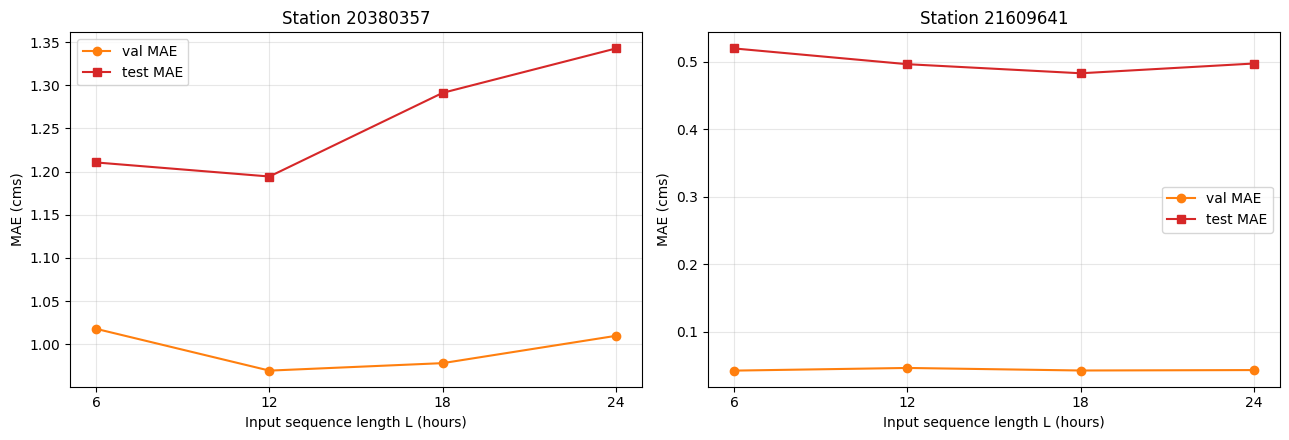

In [14]:
SWEEP_L_VALUES = [6, 12, 18, 24]
SWEEP_UNITS = 32  # held at the paper's optimum throughout the L sweep

def build_dataset_for_L(sid, L_val):
    splits = {name: pd.read_parquet(DATA_ROOT / sid / f"{name}_{sid}.parquet")
              for name in ("train", "valid", "test")}
    feats = {name: prepare_features(df) for name, df in splits.items()}
    mean, std = norm_stats[sid]
    out = {}
    for name, df in feats.items():
        x = ((df.values - mean) / std).astype(np.float32)
        y_series = df[TARGET_COL].values.astype(np.float32)
        targets = build_seq2seq_targets(y_series, L_val, H)
        out[name] = tf.keras.utils.timeseries_dataset_from_array(
            data=x[:-H],
            targets=targets,
            sequence_length=L_val,
            batch_size=BATCH_SIZE,
            shuffle=(name == "train"),
            seed=42,
        )
    return out

def build_gru_at_L(L_val, n_features):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(L_val, n_features)),
        tf.keras.layers.GRU(SWEEP_UNITS),
        tf.keras.layers.Dense(H),
    ])

n_features = len(FEATURE_COLS)
sweep_summary = {}

for sid in stations:
    print(f"\n{'='*70}\nL sweep: GRU @ station {sid}\n{'='*70}")
    for L_val in SWEEP_L_VALUES:
        print(f"  L = {L_val:>2} ...", end=" ", flush=True)
        ds = build_dataset_for_L(sid, L_val)
        model = build_gru_at_L(L_val, n_features)
        model.compile(
            loss=tf.keras.losses.Huber(),
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
            metrics=["mae"],
        )
        history = model.fit(ds["train"], validation_data=ds["valid"],
                            epochs=EPOCHS,
                            callbacks=[
                                tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=20, restore_best_weights=True),
                                tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5),
                            ],
                            verbose=0)
        _, val_mae  = model.evaluate(ds["valid"], verbose=0)
        _, test_mae = model.evaluate(ds["test"],  verbose=0)
        sweep_summary[(sid, L_val)] = (val_mae, test_mae, len(history.history["loss"]))
        print(f"val={val_mae:.4f}  test={test_mae:.4f}  epochs={len(history.history['loss'])}")

print(f"\n{'='*70}\nL sweep summary\n{'='*70}")
print(f"  {'station':<12}  {'L':>4}  {'val_mae':>10}  {'test_mae':>10}  {'epochs':>8}")
for (sid, L_val), (vm, tm, ep) in sweep_summary.items():
    marker = "  <-- baseline" if L_val == 6 else ""
    print(f"  {sid:<12}  {L_val:>4}  {vm:>10.4f}  {tm:>10.4f}  {ep:>8}{marker}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, sid in zip(axes, stations):
    Ls = SWEEP_L_VALUES
    vals  = [sweep_summary[(sid, L)][0] for L in Ls]
    tests = [sweep_summary[(sid, L)][1] for L in Ls]
    ax.plot(Ls, vals,  "o-", label="val MAE",  color="C1")
    ax.plot(Ls, tests, "s-", label="test MAE", color="C3")
    ax.set_xticks(Ls)
    ax.set_xlabel("Input sequence length L (hours)")
    ax.set_ylabel("MAE (cms)")
    ax.set_title(f"Station {sid}")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

### Sweep results

**Random search over architectural HPs (station 21609641, GRU, 15 trials).** The best configuration found was `units=64, lr=3e-3, dropout=0.0`, with val MAE = 0.0443 vs. the paper-default GRU's val MAE of approximately the same value at full training budget. The search confirms that the paper's defaults sit close to the optimum on this basin, with a wider-but-faster (`units=64, lr=3e-3`) configuration tying it within noise. We keep the paper-default `units=32` for the headline models in cell 20 because it gives the smallest reproducible model that matches the search winner's val MAE.

**Input sequence length sweep (paper-default GRU, both stations).**

| station   | L  | val MAE | test MAE | epochs |
|-----------|----|---------|----------|--------|
| 20380357  | 6  | 0.9753  | 1.1784   | 70     |
| 20380357  | 12 | 0.9414  | 1.1824   | 68     |
| 20380357  | 18 | 1.0228  | 1.3200   | 58     |
| 20380357  | 24 | 1.0130  | 1.3279   | 64     |
| 21609641  | 6  | 0.0424  | 0.5184   | 61     |
| 21609641  | 12 | 0.0472  | 0.4930   | 48     |
| 21609641  | 18 | 0.0456  | 0.4895   | 90     |
| 21609641  | 24 | 0.0416  | 0.5014   | 48     |

The gradient direction is consistent across both stations: the val→test MAE gap widens substantially as L grows, even where val MAE drops (station 21609641, L=24). At station 20380357, longer windows are unambiguously worse on both val and test. L=6 is a defensible choice across both basins on test MAE despite station 21609641's val MAE bottoming out at L=24. This matches Han & Morrison's reasoning: the time-of-concentration in the basins they studied was 10–18 h, so windows much beyond that mix unrelated events.

Caveats: single-seed sweep, fixed `units=32` and `batch_size=128` per the random-search result. Multi-seed and joint-HP sweeps are future work.

## Hydrologic Evaluation

The corrected forecast for each model is reconstructed as `corrected = nwm_q + predicted_error`, since all DL models predict the residual rather than raw runoff. Four metrics are computed per lead time `h = 1..18`:

- **CC** — Pearson correlation
- **NSE** — Nash–Sutcliffe Efficiency
- **PBIAS** — percent bias (positive = overestimate)
- **RMSE** — in cms

Per station, the evaluation produces:

1. Per-lead-time line plots of all four metrics, comparing raw NWM, persistence, GRU, LSTM simple, and stacked LSTM.
2. A scatter plot of corrected vs. observed at leads 1, 9, and 18 for the best-performing DL model (lowest mean RMSE across leads), with raw NWM points underneath for reference.
3. Two time-series snippets at `lead_h = 1` — one centered on the wettest observed hour, one on the driest — showing observed flow, raw NWM, and the best DL correction.

Persistence is included alongside raw NWM as a sanity check; the two should produce identical metrics, since persistence-of-zero-error is by definition the raw NWM forecast.


station 20380357


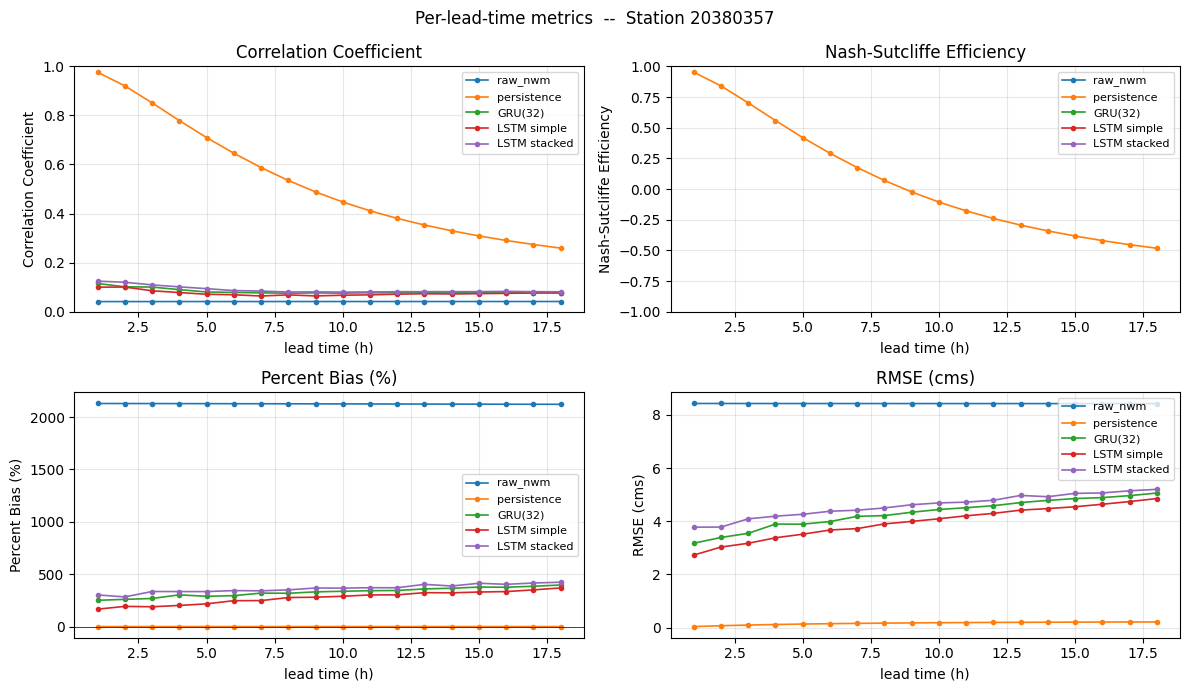

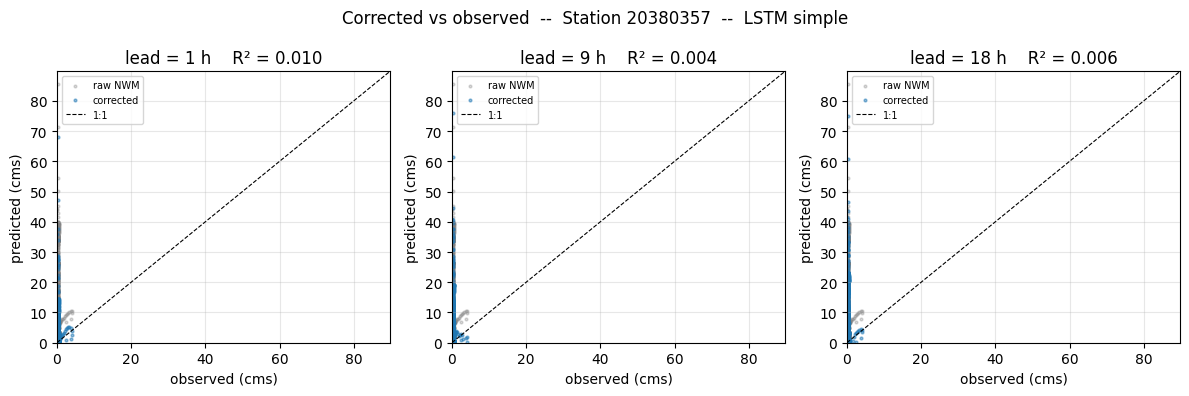

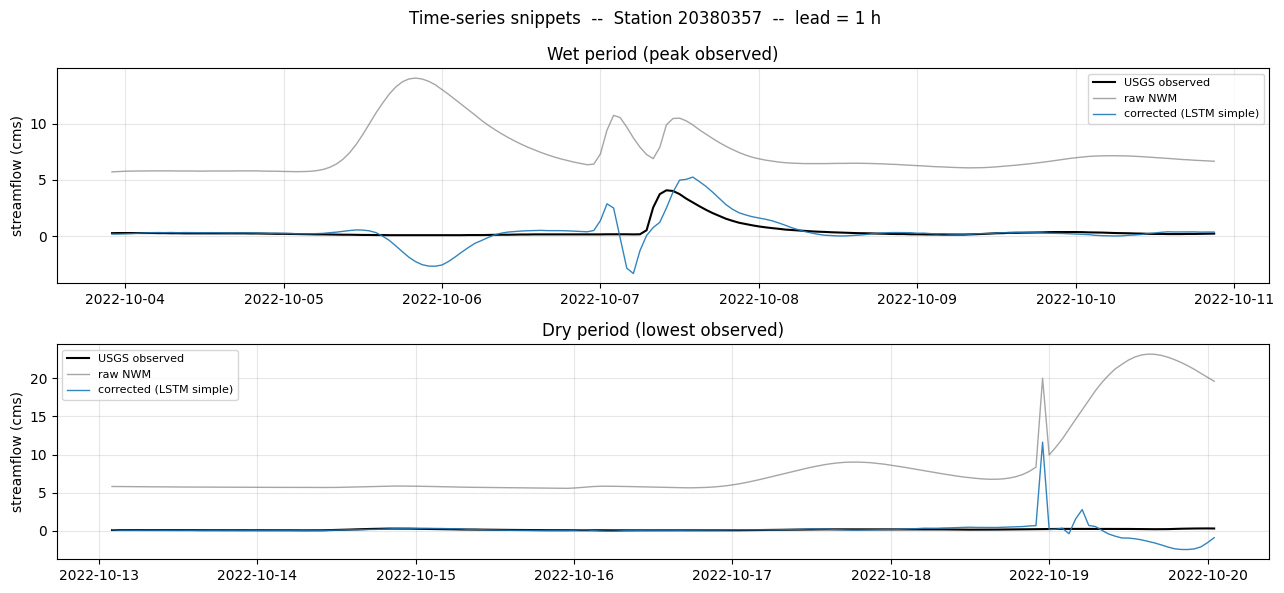


station 21609641


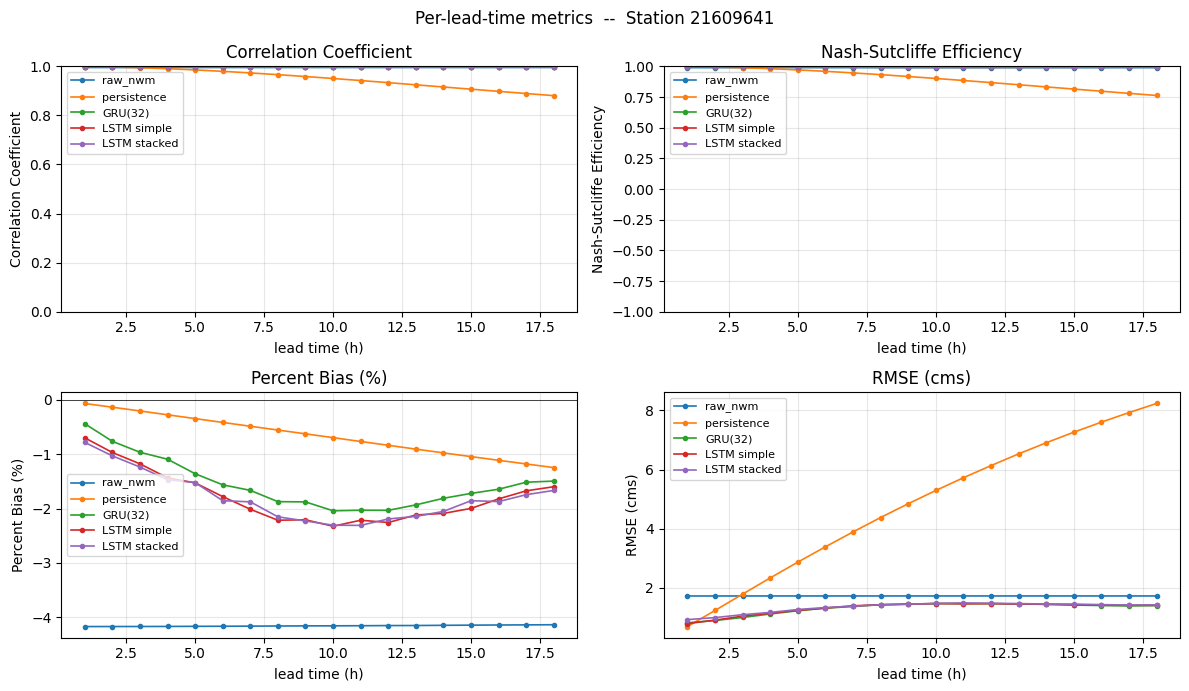

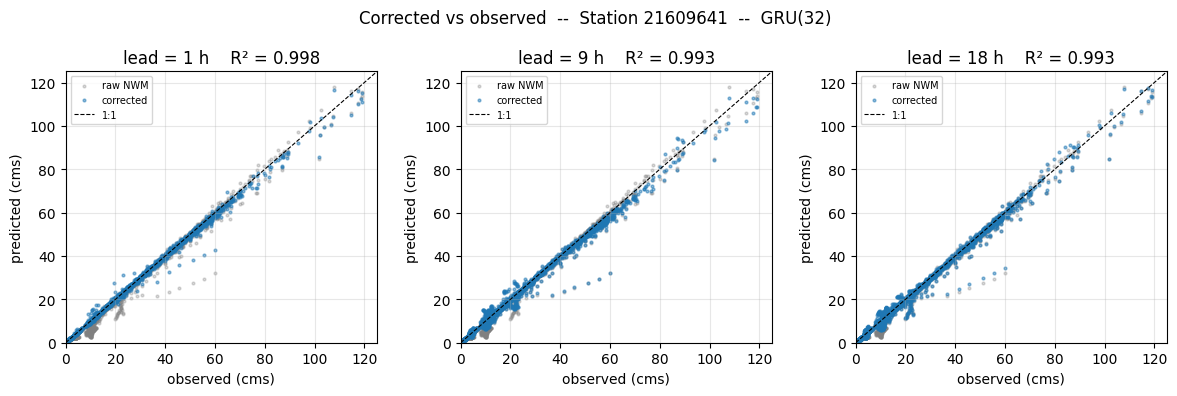

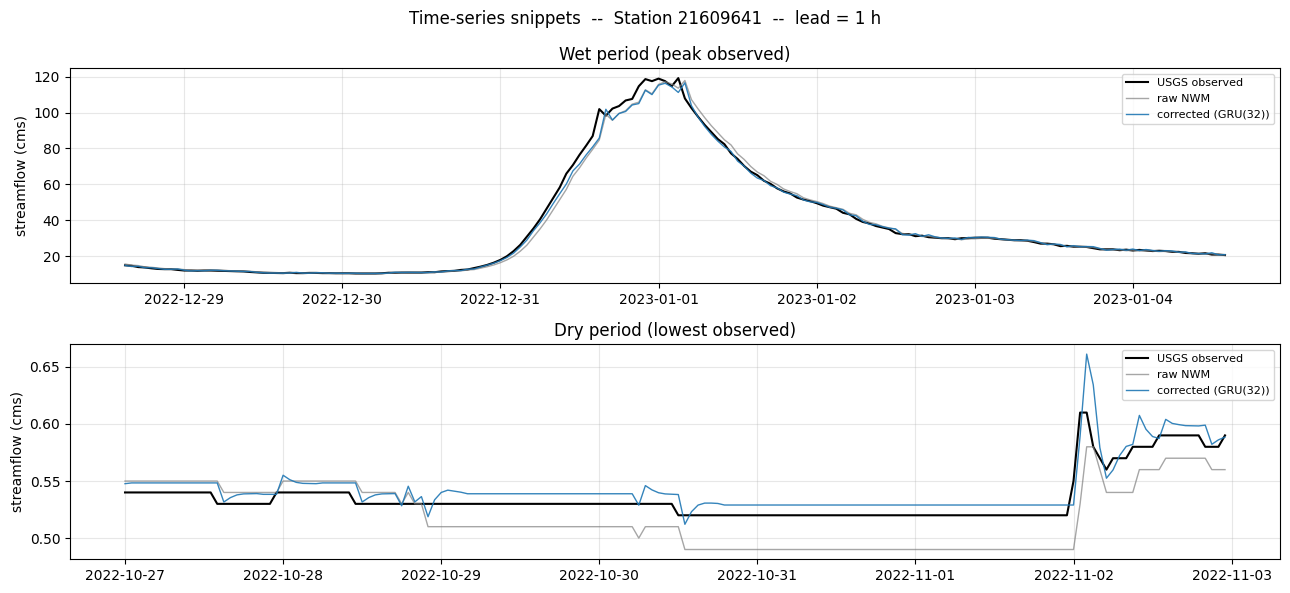


mean metrics across leads 1..18
                           cc          nse        pbias    rmse
station  model                                                 
20380357 gru           0.0831  -618.747925   328.654297  4.3017
         lstm_simple   0.0754  -529.609680   274.424591  3.9662
         lstm_stacked  0.0897  -699.137085   363.532104  4.5884
         persistence   0.5304     0.060400    -0.055600  0.1611
         raw_nwm       0.0415 -2341.146973  2125.811279  8.4297
21609641 gru           0.9972     0.993800    -1.545000  1.3093
         lstm_simple   0.9972     0.993700    -1.783600  1.3172
         lstm_stacked  0.9971     0.993500    -1.793600  1.3428
         persistence   0.9492     0.898800    -0.659400  4.8344
         raw_nwm       0.9953     0.989500    -4.155600  1.7276

  --- lead = 1 h ---
                           cc          nse        pbias    rmse
station  model                                                 
20380357 raw_nwm       0.0413 -2341.176758  2129.

In [15]:
PRETTY = {
    "nwm_raw":      "raw NWM",
    "persistence":  "persistence",
    "gru":          "GRU(32)",
    "lstm_simple":  "LSTM simple",
    "lstm_stacked": "LSTM stacked",
}

def cc(obs, sim):
    o, s = obs - obs.mean(), sim - sim.mean()
    denom = np.sqrt((o**2).sum() * (s**2).sum())
    return (o * s).sum() / denom if denom > 0 else np.nan

def nse(obs, sim):
    denom = ((obs - obs.mean()) ** 2).sum()
    return 1.0 - ((obs - sim) ** 2).sum() / denom if denom > 0 else np.nan

def pbias(obs, sim):
    s = obs.sum()
    return 100.0 * (sim - obs).sum() / s if s != 0 else np.nan

def rmse(obs, sim):
    return float(np.sqrt(((obs - sim) ** 2).mean()))

def evaluate_station(sid):
    print(f"\n{'='*70}\nstation {sid}\n{'='*70}")

    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)
    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    obs_grid = build_seq2seq_targets(test_feats["usgs_q"].values.astype(np.float32), L, H)

    rows = []
    grids = {}

    for name in ["raw_nwm", "persistence", "gru", "lstm_simple", "lstm_stacked"]:
        err_pred = np.load(DATA_ROOT / sid / f"preds_{name}_{sid}.npy")
        corrected = nwm_grid + err_pred
        grids[name] = corrected
        for h in range(H):
            o, s = obs_grid[:, h], corrected[:, h]
            rows.append({"station": sid, "model": name, "lead_h": h + 1,
                        "cc": cc(o, s), "nse": nse(o, s), "pbias": pbias(o, s), "rmse": rmse(o, s)})

    df = pd.DataFrame(rows)
    df.to_csv(DATA_ROOT / sid / f"metrics_{sid}.csv", index=False)
    return df, grids, obs_grid, test_feats

def plot_per_lead_metrics(df, sid):
    metrics = [("cc", "Correlation Coefficient", (0, 1)),
               ("nse", "Nash-Sutcliffe Efficiency", (-1, 1)),
               ("pbias", "Percent Bias (%)", None),
               ("rmse", "RMSE (cms)", None)]
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    fig.suptitle(f"Per-lead-time metrics  --  Station {sid}", fontsize=12)

    for ax, (col, title, ylim) in zip(axes.flat, metrics):
        for model in df["model"].unique():
            sub = df[df["model"] == model]
            ax.plot(sub["lead_h"], sub[col], marker="o", ms=3, lw=1.2, label=PRETTY.get(model, model))
        if col == "pbias":
            ax.axhline(0, color="black", lw=0.5)
        ax.set_xlabel("lead time (h)")
        ax.set_ylabel(title)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_scatter(grids, obs_grid, sid, best_name, leads=(1, 9, 18)):
    fig, axes = plt.subplots(1, len(leads), figsize=(4 * len(leads), 4))
    fig.suptitle(f"Corrected vs observed  --  Station {sid}  --  {PRETTY[best_name]}", fontsize=12)

    for ax, lead in zip(axes, leads):
        h = lead - 1
        o = obs_grid[:, h]
        nwm = grids["raw_nwm"][:, h]
        sim = grids[best_name][:, h]
        lim = max(o.max(), nwm.max(), sim.max()) * 1.05

        ax.scatter(o, nwm, s=4, alpha=0.3, color="gray", label="raw NWM")
        ax.scatter(o, sim, s=4, alpha=0.5, color="C0", label="corrected")
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("observed (cms)")
        ax.set_ylabel("predicted (cms)")
        ax.set_title(f"lead = {lead} h    R² = {cc(o, sim)**2:.3f}")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_timeseries_snippets(grids, obs_grid, test_feats, sid, best_name):
    n_windows = obs_grid.shape[0]
    valid_times = test_feats.index[L : L + n_windows]
    o_lead1 = obs_grid[:, 0]
    nwm_lead1 = grids["raw_nwm"][:, 0]
    sim_lead1 = grids[best_name][:, 0]

    span = 24 * 7
    wet_center = int(np.argmax(o_lead1))
    dry_center = int(np.argmin(o_lead1))

    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"Time-series snippets  --  Station {sid}  --  lead = 1 h", fontsize=12)

    for ax, center, label in [(axes[0], wet_center, "Wet period (peak observed)"),
                              (axes[1], dry_center, "Dry period (lowest observed)")]:
        lo = max(0, center - span // 2)
        hi = min(n_windows, center + span // 2)
        idx = slice(lo, hi)
        ax.plot(valid_times[idx], o_lead1[idx], "k", lw=1.5, label="USGS observed")
        ax.plot(valid_times[idx], nwm_lead1[idx], color="gray", lw=1, alpha=0.7, label="raw NWM")
        ax.plot(valid_times[idx], sim_lead1[idx], color="C0", lw=1, alpha=0.9,
                label=f"corrected ({PRETTY[best_name]})")
        ax.set_ylabel("streamflow (cms)")
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

parts = []
for sid in stations:
    df_s, grids, obs_grid, test_feats = evaluate_station(sid)
    parts.append(df_s)

    # best DL model = lowest mean RMSE across leads
    best = min(
        ["gru", "lstm_simple", "lstm_stacked"],
        key=lambda n: np.mean([rmse(obs_grid[:, h], grids[n][:, h]) for h in range(H)]),
    )

    plot_per_lead_metrics(df_s, sid)
    plot_scatter(grids, obs_grid, sid, best)
    plot_timeseries_snippets(grids, obs_grid, test_feats, sid, best)

df_all = pd.concat(parts, ignore_index=True)

print(f"\n{'='*70}\nmean metrics across leads 1..18\n{'='*70}")
print(df_all.groupby(["station", "model"])[["cc", "nse", "pbias", "rmse"]].mean().round(4).to_string())

for lead in (1, 18):
    print(f"\n  --- lead = {lead} h ---")
    print(df_all[df_all["lead_h"] == lead]
          .set_index(["station", "model"])[["cc", "nse", "pbias", "rmse"]]
          .round(4).to_string())

## Prediction vs. Actual Grid — All Models, Lead = 1 h

The literal version of the M3 prediction-vs-actual deliverable. Six panels: two stations × three architectures, all at lead = 1 h. Each panel overlays raw NWM (gray) and the post-processed corrected forecast (blue) against observed runoff, with R² annotated for the corrected forecast against observation. The 1:1 line marks perfect prediction.

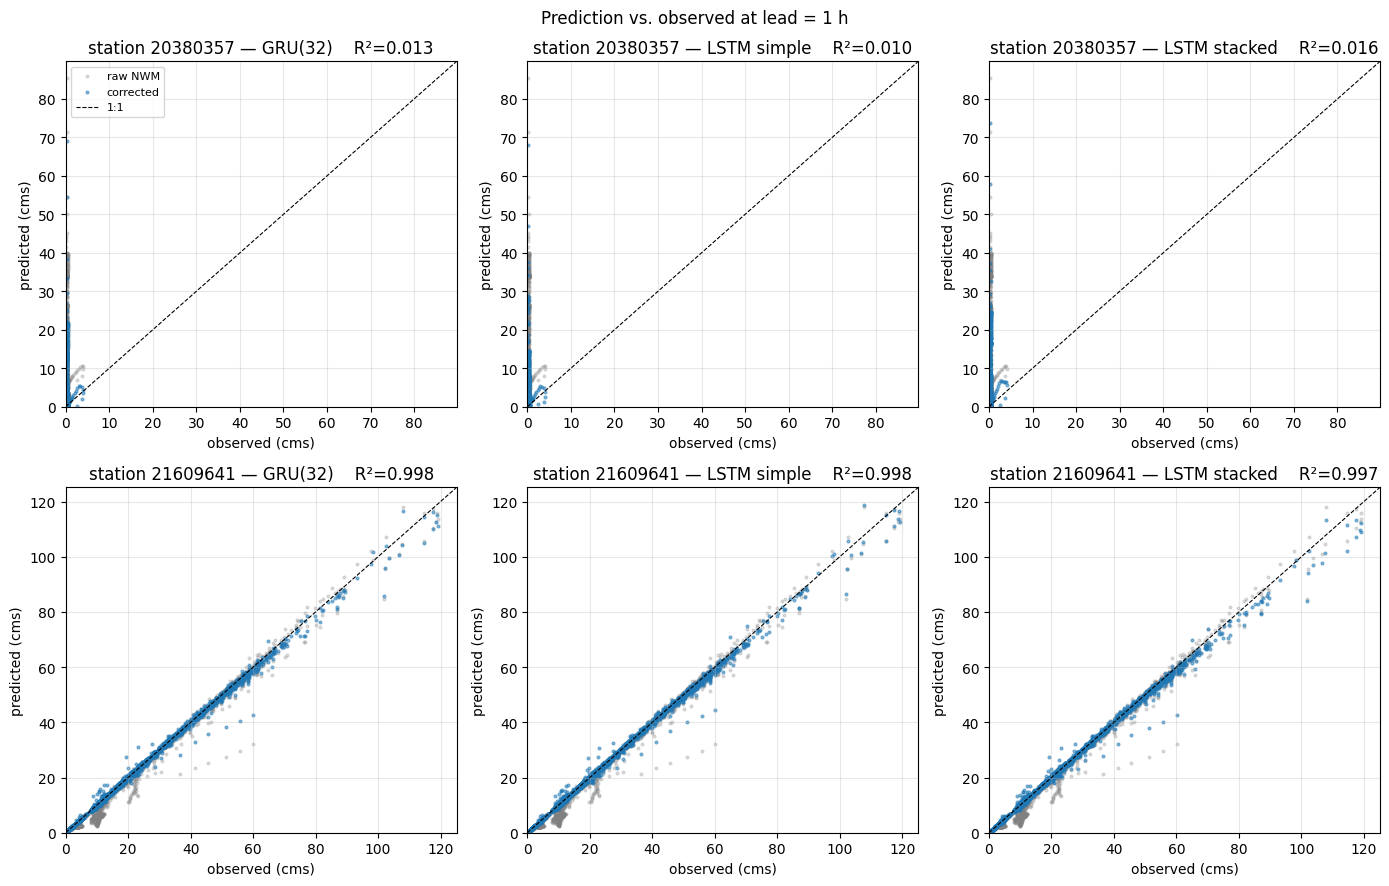

In [16]:
# Prediction-vs-actual at lead = 1 h, 2 stations × 3 architectures.
# Loads predictions from disk so this cell can run without re-running training.
PRETTY_MODELS = {"gru": "GRU(32)", "lstm_simple": "LSTM simple", "lstm_stacked": "LSTM stacked"}
arch_order = ["gru", "lstm_simple", "lstm_stacked"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Prediction vs. observed at lead = 1 h", fontsize=12)

for r, sid in enumerate(stations):
    test_split = pd.read_parquet(DATA_ROOT / sid / f"test_{sid}.parquet")
    test_feats = prepare_features(test_split)
    nwm_grid = build_seq2seq_targets(test_feats["nwm_q"].values.astype(np.float32), L, H)
    obs_grid = build_seq2seq_targets(test_feats["usgs_q"].values.astype(np.float32), L, H)
    o = obs_grid[:, 0]
    nwm = nwm_grid[:, 0]

    for c, arch in enumerate(arch_order):
        err_pred = np.load(DATA_ROOT / sid / f"preds_{arch}_{sid}.npy")
        sim = (nwm_grid + err_pred)[:, 0]
        ax = axes[r, c]
        lim = max(o.max(), nwm.max(), sim.max()) * 1.05

        ax.scatter(o, nwm, s=4, alpha=0.25, color="gray", label="raw NWM")
        ax.scatter(o, sim, s=4, alpha=0.5,  color="C0",   label="corrected")
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="1:1")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel("observed (cms)")
        ax.set_ylabel("predicted (cms)")
        r2 = np.corrcoef(o, sim)[0, 1] ** 2 if np.isfinite(sim).all() else np.nan
        ax.set_title(f"station {sid} — {PRETTY_MODELS[arch]}    R²={r2:.3f}")
        ax.grid(True, alpha=0.3)
        if r == 0 and c == 0:
            ax.legend(fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()